# Task 5 – Edge and Contour Detection

## Objective

The objective of this task is to detect edges using the Canny edge detector and identify object boundaries. The thresholds are adjusted until the detected contours correspond to the actual objects placed in the scene.

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [6]:
image = cv2.imread("raw-captures/objects-front.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(image)

[[[212 218 223]
  [212 218 223]
  [213 219 224]
  ...
  [197 206 210]
  [198 207 211]
  [198 207 211]]

 [[213 219 224]
  [213 219 224]
  [213 219 224]
  ...
  [198 207 211]
  [198 207 211]
  [198 207 211]]

 [[214 220 225]
  [214 220 225]
  [213 219 224]
  ...
  [199 208 212]
  [198 207 211]
  [197 206 210]]

 ...

 [[ 89 104 137]
  [ 89 104 137]
  [ 90 105 138]
  ...
  [ 89 102 134]
  [ 92 105 137]
  [ 88 101 133]]

 [[ 88 103 136]
  [ 88 103 136]
  [ 90 105 138]
  ...
  [ 88 101 133]
  [ 93 106 138]
  [ 84  97 129]]

 [[ 87 102 135]
  [ 87 102 135]
  [ 90 105 138]
  ...
  [ 84  97 129]
  [ 92 105 137]
  [ 82  95 127]]]


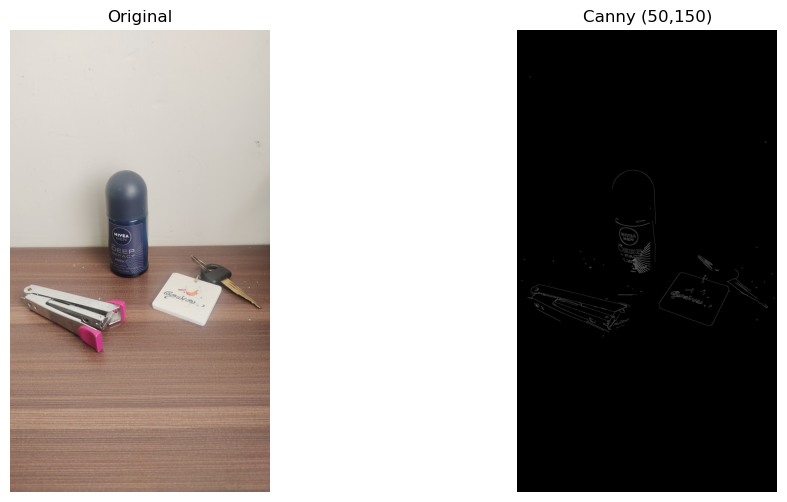

In [52]:
blur = cv2.GaussianBlur(gray, (7, 7), 0)

edges = cv2.Canny(blur, 60, 150)

plt.figure(figsize=(12,6))

plt.subplot(121)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(edges, cmap="gray")
plt.title("Canny (50,150)")
plt.axis("off")

plt.show()

# Observations

Initially, Canny edge detection was producing many unwanted edges from the wooden table texture and small background details. To improve the result, I applied Gaussian Blur before performing edge detection.

After tuning the parameters, the final Canny output significantly reduced the background noise while preserving the edges of the main objects. The deodorant bottle, stapler, and key with key tag were all clearly distinguishable from the background.

Compared to the initial output, the final result contained fewer false edges and provided cleaner object boundaries, making it more suitable for contour detection in the next step.

**Final Threshold Values:** (60, 150)

**Preprocessing Applied:** Gaussian Blur (7 × 7)

**Number of Attempts:** 3

**Actual Number of Objects:** 3

The tuned parameters provided a good balance between suppressing background texture and retaining the important edges of the objects.

Contours Found: 301
Contours After Filtering: 52


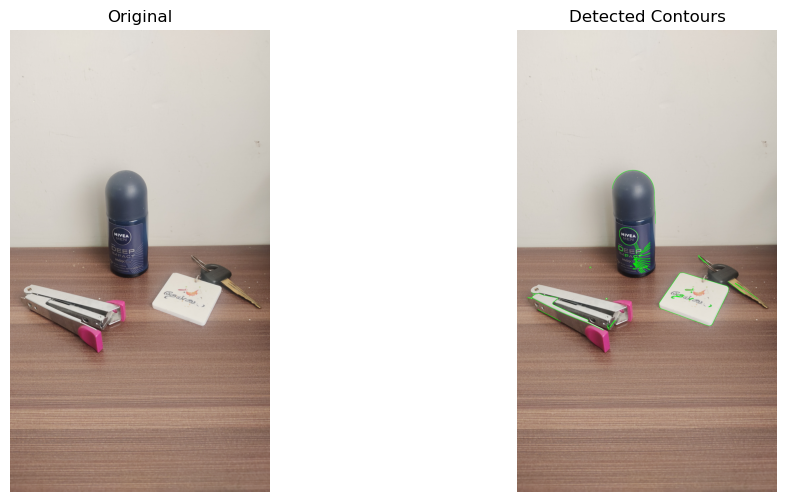

In [108]:
blur = cv2.GaussianBlur(gray,(5,5),0)

edges = cv2.Canny(blur,70,170)

contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image_rgb.copy()

output = image_rgb.copy()

filtered = 0

for contour in contours:
    area = cv2.contourArea(contour)

    if area > 100:
        cv2.drawContours(output, [contour], -1, (0,255,0), 2)
        filtered += 1

print("Contours Found:", len(contours))
print("Contours After Filtering:", filtered)

plt.figure(figsize=(12,6))

plt.subplot(121)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(output)
plt.title("Detected Contours")
plt.axis("off")

plt.show()

## Observations

The Canny edge detector initially detected **301 contours**, including many unwanted edges caused by the wooden table texture, shadows, reflections from the metallic stapler, printed text on the key tag, and other small details in the image.

To reduce noise, contour area filtering was applied by ignoring contours with an area less than **100 pixels**. This reduced the number of displayed contours from **301 to 52**, while preserving the larger and more meaningful contours corresponding to the objects.

Although **52 contours** were still detected, this is expected because each object contains multiple edges, logos, printed text, and reflective surfaces that generate separate contours. The filtering step significantly reduced noise and produced a cleaner visualization without removing important object features.scene.